# Probability Density Functions

In [1]:
from random import sample
import matplotlib
from matplotlib.lines import lineStyles
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas._libs import interval
from scipy.stats import expon, f, trimboth, norm
from scipy.integrate import simpson
import seaborn as sns

## Normal distribution PDF

We start with the PDF of the normal distribution. Formula of normal distribution PDF is:

$$
\frac{1}{\sqrt{2\pi\sigma^2}} e^{-\frac{(x-\mu)^2}{2\sigma^2}}
$$

Let's evaulate range of weights (NSFG birth data) using Normal PDF.

In [2]:
birth = pd.read_csv("./data/2002FemPreg_after_01.csv")
birth

,caseid,pregordr,howpreg_n,howpreg_p,moscurrp,nowprgdk,pregend1,pregend2,nbrnaliv,multbrth,...,religion_i,metro_i,basewgt,adj_mod_basewgt,finalwgt,secu_p,sest,cmintvw,totalwgt_lb,totalwgt_kg
0,1,1,NaN,NaN,NaN,NaN,6.0,NaN,1.0,NaN,...,0,0,3410.389399,3869.349602,6448.271112,2,9,1231,8.8125,3.997283
1,1,2,NaN,NaN,NaN,NaN,6.0,NaN,1.0,NaN,...,0,0,3410.389399,3869.349602,6448.271112,2,9,1231,7.8750,3.572040
2,2,1,NaN,NaN,NaN,NaN,5.0,NaN,3.0,5.0,...,0,0,7226.301740,8567.549110,12999.542264,2,12,1231,9.1250,4.139030
3,2,2,NaN,NaN,NaN,NaN,6.0,NaN,1.0,NaN,...,0,0,7226.301740,8567.549110,12999.542264,2,12,1231,7.0000,3.175147
4,2,3,NaN,NaN,NaN,NaN,6.0,NaN,1.0,NaN,...,0,0,7226.301740,8567.549110,12999.542264,2,12,1231,6.1875,2.806603
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13588,12571,1,NaN,NaN,NaN,NaN,6.0,NaN,1.0,NaN,...,0,0,4670.540953,5795.692880,6269.200989,1,78,1227,6.1875,2.806603
13589,12571,2,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,...,0,0,4670.540953,5795.692880,6269.200989,1,78,1227,NaN,NaN
13590,12571,3,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,...,0,0,4670.540953,5795.692880,6269.200989,1,78,1227,NaN,NaN
13591,12571,4,NaN,NaN,NaN,NaN,6.0,NaN,1.0,NaN,...,0,0,4670.540953,5795.692880,6269.200989,1,78,1227,7.5000,3.401943


In [3]:
trimmed_weight = trimboth(birth["totalwgt_kg"].dropna(), 0.01)

In [4]:
trim_mean, trim_std = np.mean(trimmed_weight), np.std(trimmed_weight)
trim_high, trim_low = trim_mean + trim_std * 4, trim_mean - trim_std * 4

In [5]:
x_ticks = np.linspace(trim_low, trim_high, 201)

In [6]:
norm_dist = norm.pdf(x_ticks, trim_mean, trim_std)
norm_pdf = pd.Series(norm_dist, index=x_ticks)
norm_pdf

1.021660    0.000234
1.044542    0.000274
1.067424    0.000321
1.090306    0.000375
1.113188    0.000438
              ...   
5.506501    0.000438
5.529383    0.000375
5.552265    0.000321
5.575146    0.000274
5.598028    0.000234
Length: 201, dtype: float64

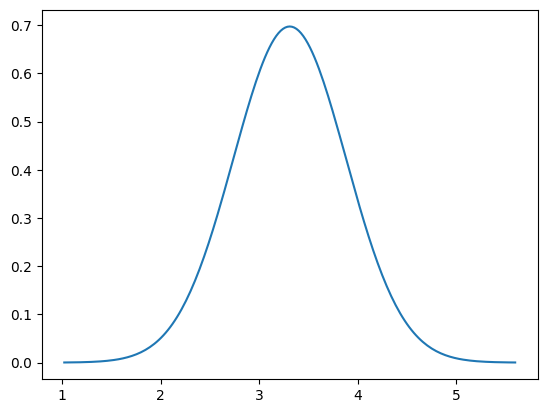

In [7]:
fig, ax = plt.subplots()
ax.plot(norm_pdf.index, norm_pdf)
plt.show()

We know that area under PDF equals to 1, let's test that too.

In [8]:
simpson(x=x_ticks, y=norm_dist)

np.float64(0.999936657318706)

If we wanted to find the fraction of birth weights between 1 and 2 kgs, we could do:

In [9]:
x_between_1_2 = np.linspace(1, 2, 201)
y_between_1_2 = norm.pdf(x_between_1_2, trim_mean, trim_std)
simpson(x=x_between_1_2, y=y_between_1_2)

np.float64(0.01099083812558587)

We can also find the fraction by $F_X(2) - F_X(1)$

In [10]:
norm.cdf(2, trim_mean, trim_std) - norm.cdf(1, trim_mean, trim_std)

np.float64(0.010990838120956284)

## Kernel Density Estimation (KDE)

We can use KDE to estimate a PDF from the discrete data.

In [11]:
birth_weights = birth["totalwgt_kg"].dropna()
trimmed_weight = pd.Series(trimboth(birth_weights, 0.02))

In [12]:
np.random.seed(3)
n = 500
sample_birth_weights = trimmed_weight.sample(n)
sample_birth_weights

450     2.778253
6632    3.827186
5131    3.118448
2005    2.976700
4431    3.288545
          ...   
295     2.097865
5335    3.316894
3344    3.373593
4896    3.231846
455     2.579807
Length: 500, dtype: float64

In [13]:
weight_kde_pmf = pd.Series(1 / n, index=sample_birth_weights)
weight_kde_pmf
len(weight_kde_pmf)

500

We can find the optimal $h$ using _Scott's rule of thumb_.

$$
h \approx 1.06 \cdot \hat{\sigma}n^{\frac{1}{5}}
$$

In [14]:
x_vals = np.linspace(0, 7, 1000)
h = 1.06 * sample_birth_weights.std() * len(sample_birth_weights) ** (-1 / 5)
h

np.float64(0.15986553305845413)

In [15]:
norm_dist = norm.pdf(
    x_vals, loc=sample_birth_weights.mean(), scale=sample_birth_weights.std()
)
norm_pdf = pd.Series(norm_dist, index=x_vals)
norm_pdf

0.000000    9.398033e-10
0.007007    1.023979e-09
0.014014    1.115493e-09
0.021021    1.214967e-09
0.028028    1.323075e-09
                ...     
6.971972    2.783698e-11
6.978979    2.536401e-11
6.985986    2.310658e-11
6.992993    2.104629e-11
7.000000    1.916625e-11
Length: 1000, dtype: float64

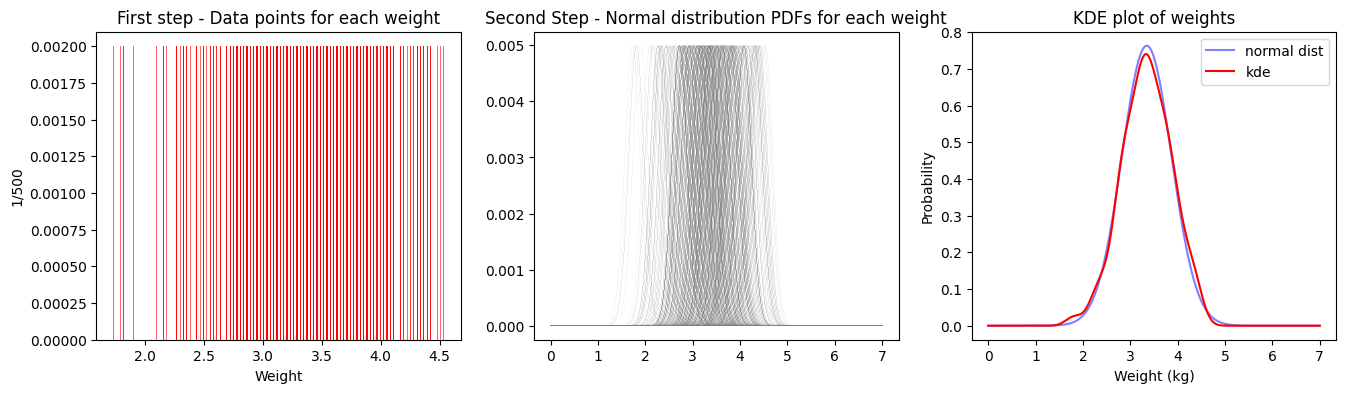

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].bar(weight_kde_pmf.index, weight_kde_pmf, width=0.01, color="red", alpha=0.6)
kde_total = np.zeros_like(x_vals)
for point in sample_birth_weights:
    kernel = norm.pdf(x_vals, loc=point, scale=h) * (1 / n)
    ax[1].plot(x_vals, kernel, color="gray", alpha=0.5, linestyle="-", linewidth=0.1)
    kde_total += kernel

ax[2].plot(norm_pdf.index, norm_pdf, color="blue", alpha=0.5, label="normal dist")
ax[2].plot(x_vals, kde_total, color="red", label="kde")

ax[0].set_xlabel("Weight")
ax[0].set_ylabel(f"1/{n}")
ax[0].set_title("First step - Data points for each weight")

ax[1].set_title("Second Step - Normal distribution PDFs for each weight")

ax[2].set_xlabel("Weight (kg)")
ax[2].set_ylabel("Probability")
ax[2].set_title("KDE plot of weights")
ax[2].legend()


plt.show()

We have our KDE plot. In some cases, like here where we have too many data points, it is better to use KDE plot instead of a histogram.

We can calculate the area below our KDE plot to ensure that our KDE plot is also a PDF.

In [17]:
simpson(x=x_vals, y=kde_total)

np.float64(1.0)

## The Distribution Framework

At this point, we have a complete set of ways to represent distributions: PMFs, CDFs and PDFs. Now, let's learn how to transform one to another.

<img src="/notes/ts/assets/distribution_framework.png" height="300"/>

Let's practice these transformations and representations using the popular "44 babies in one 24-hour period" dataset.

In [18]:
colspecs = [(1, 8), (9, 16), (17, 24), (25, 32)]
column_names = ["time", "sex", "weight_g", "minutes"]
boom = pd.read_fwf(
    "./data/babyboom.dat", colspecs=colspecs, names=column_names, skiprows=59
)
boom

,time,sex,weight_g,minutes
0,5,1,3837,5
1,104,1,3334,64
2,118,2,3554,78
3,155,2,3838,115
4,257,2,3625,177
5,405,1,2208,245
6,407,1,1745,247
7,422,2,2846,262
8,431,2,3166,271
9,708,2,3520,428


In [19]:
intervals = boom["minutes"].diff().dropna()
intervals

1      59.0
2      14.0
3      37.0
4      62.0
5      68.0
6       2.0
7      15.0
8       9.0
9     157.0
10     27.0
11     37.0
12      2.0
13     55.0
14     86.0
15     14.0
16      4.0
17     40.0
18     36.0
19     47.0
20      9.0
21     61.0
22      1.0
23     26.0
24     13.0
25     28.0
26     77.0
27     26.0
28     45.0
29     25.0
30     18.0
31     29.0
32     15.0
33     38.0
34      2.0
35      2.0
36     19.0
37     27.0
38     14.0
39     13.0
40     19.0
41     54.0
42     70.0
43     28.0
Name: minutes, dtype: float64

In [20]:
intervals_pmf = intervals.value_counts(normalize=True).sort_index()
intervals_pmf

minutes
1.0      0.023256
2.0      0.093023
4.0      0.023256
9.0      0.046512
13.0     0.046512
14.0     0.069767
15.0     0.046512
18.0     0.023256
19.0     0.046512
25.0     0.023256
26.0     0.046512
27.0     0.046512
28.0     0.046512
29.0     0.023256
36.0     0.023256
37.0     0.046512
38.0     0.023256
40.0     0.023256
45.0     0.023256
47.0     0.023256
54.0     0.023256
55.0     0.023256
59.0     0.023256
61.0     0.023256
62.0     0.023256
68.0     0.023256
70.0     0.023256
77.0     0.023256
86.0     0.023256
157.0    0.023256
Name: proportion, dtype: float64

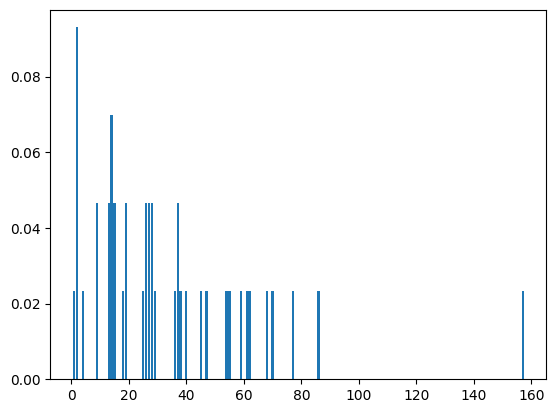

In [21]:
fig, ax = plt.subplots()
ax.bar(intervals_pmf.index, intervals_pmf)
plt.show()

In [22]:
intervals_cdf = intervals_pmf.cumsum()
intervals_cdf

minutes
1.0      0.023256
2.0      0.116279
4.0      0.139535
9.0      0.186047
13.0     0.232558
14.0     0.302326
15.0     0.348837
18.0     0.372093
19.0     0.418605
25.0     0.441860
26.0     0.488372
27.0     0.534884
28.0     0.581395
29.0     0.604651
36.0     0.627907
37.0     0.674419
38.0     0.697674
40.0     0.720930
45.0     0.744186
47.0     0.767442
54.0     0.790698
55.0     0.813953
59.0     0.837209
61.0     0.860465
62.0     0.883721
68.0     0.906977
70.0     0.930233
77.0     0.953488
86.0     0.976744
157.0    1.000000
Name: proportion, dtype: float64

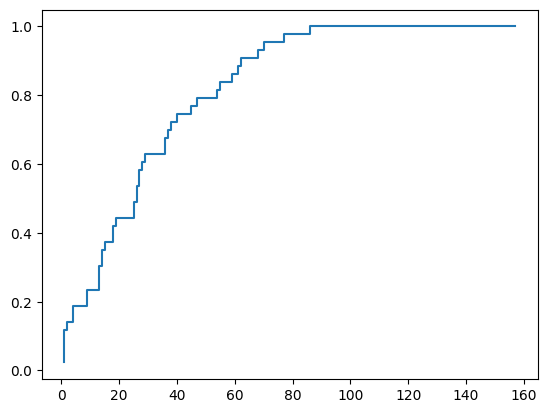

In [23]:
fig, ax = plt.subplots()
ax.step(intervals_cdf.index, intervals_cdf)
plt.show()

In [24]:
intervals_pmf_from_cdf = intervals_cdf.diff().fillna(intervals_cdf.iloc[0])
intervals_pmf_from_cdf

minutes
1.0      0.023256
2.0      0.093023
4.0      0.023256
9.0      0.046512
13.0     0.046512
14.0     0.069767
15.0     0.046512
18.0     0.023256
19.0     0.046512
25.0     0.023256
26.0     0.046512
27.0     0.046512
28.0     0.046512
29.0     0.023256
36.0     0.023256
37.0     0.046512
38.0     0.023256
40.0     0.023256
45.0     0.023256
47.0     0.023256
54.0     0.023256
55.0     0.023256
59.0     0.023256
61.0     0.023256
62.0     0.023256
68.0     0.023256
70.0     0.023256
77.0     0.023256
86.0     0.023256
157.0    0.023256
Name: proportion, dtype: float64

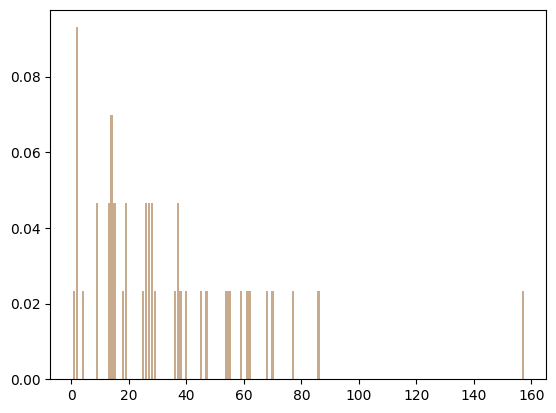

In [25]:
fig, ax = plt.subplots()
ax.bar(intervals_pmf_from_cdf.index, intervals_pmf_from_cdf, alpha=0.4)
ax.bar(intervals_pmf.index, intervals_pmf, alpha=0.4)
plt.show()

We can use `.allclose()` to check if there are any differences between the first and the second intervals PMF.

In [26]:
np.allclose(intervals_pmf, intervals_pmf_from_cdf)

True

We converted a PMF to CDF, then CDF to PMF, now let's create a KDE plot using the PMF.

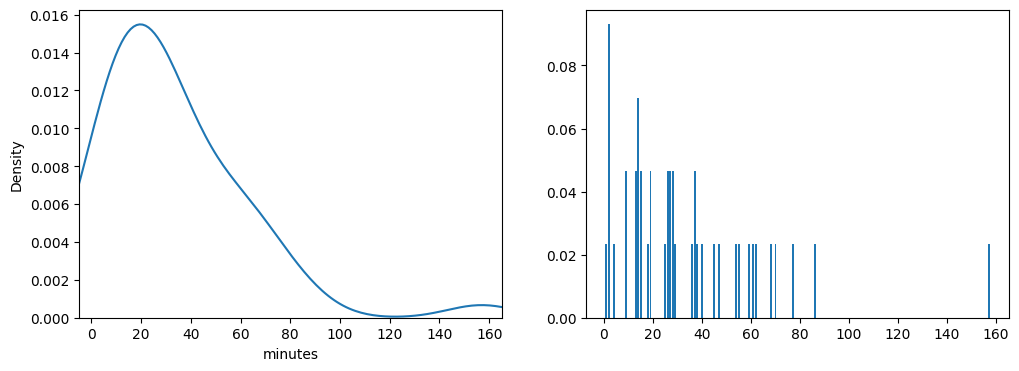

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.kdeplot(intervals, ax=ax[0], bw_method="scott")
ax[1].bar(intervals_pmf.index, intervals_pmf)
ax[0].set_xlim(-5, 165)
plt.show()

Let's see how the CDF looks again.

In [28]:
intervals_cdf = intervals_pmf.cumsum()
intervals_cdf

minutes
1.0      0.023256
2.0      0.116279
4.0      0.139535
9.0      0.186047
13.0     0.232558
14.0     0.302326
15.0     0.348837
18.0     0.372093
19.0     0.418605
25.0     0.441860
26.0     0.488372
27.0     0.534884
28.0     0.581395
29.0     0.604651
36.0     0.627907
37.0     0.674419
38.0     0.697674
40.0     0.720930
45.0     0.744186
47.0     0.767442
54.0     0.790698
55.0     0.813953
59.0     0.837209
61.0     0.860465
62.0     0.883721
68.0     0.906977
70.0     0.930233
77.0     0.953488
86.0     0.976744
157.0    1.000000
Name: proportion, dtype: float64

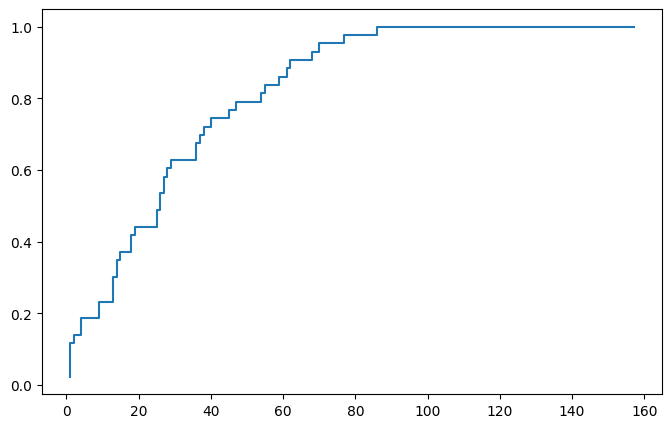

In [29]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.step(intervals_cdf.index, intervals_cdf)
plt.show()

It looks exponential CDF.

In [30]:
x_ticks = np.arange(0, np.max(intervals))
print(x_ticks)

[  0.   1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.
  14.  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.
  28.  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.
  42.  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.
  56.  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.
  70.  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.
  84.  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.
  98.  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 110. 111.
 112. 113. 114. 115. 116. 117. 118. 119. 120. 121. 122. 123. 124. 125.
 126. 127. 128. 129. 130. 131. 132. 133. 134. 135. 136. 137. 138. 139.
 140. 141. 142. 143. 144. 145. 146. 147. 148. 149. 150. 151. 152. 153.
 154. 155. 156.]


In [31]:
params = expon.fit(intervals)
exp_cdf = pd.Series(
    expon.cdf(x=x_ticks, loc=intervals.min(), scale=intervals.std()),
    index=x_ticks,
)
exp_cdf

0.0      0.000000
1.0      0.000000
2.0      0.033262
3.0      0.065418
4.0      0.096505
           ...   
152.0    0.993952
153.0    0.994153
154.0    0.994348
155.0    0.994536
156.0    0.994718
Length: 157, dtype: float64

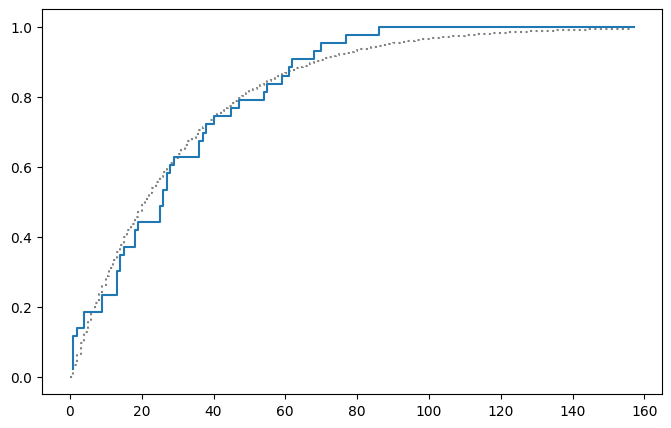

In [32]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.step(exp_cdf.index, exp_cdf, linestyle=":", color="gray")
ax.step(intervals_cdf.index, intervals_cdf)
plt.show()

it looks like an exponential cdf, but it doesn't really fit.

## Exercises

### World cup

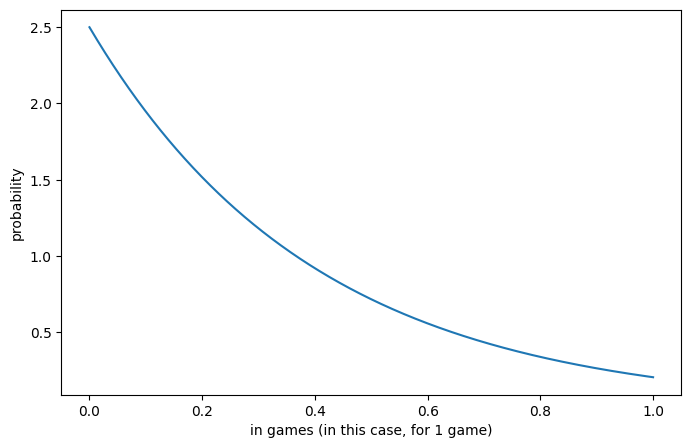

In [33]:
x_ticks = np.linspace(0, 1, 1000)
first_goal = pd.Series(expon.pdf(x=x_ticks, scale=(1 / 2.5)), index=x_ticks)
first_goal
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(first_goal.index, first_goal)
ax.set_ylabel("probability")
ax.set_xlabel("in games (in this case, for 1 game)")
plt.show()

to calculate the first goal getting scored by the halftime, we can use `simpson` again.

In [34]:
x_halftime = np.linspace(0, 0.5, 1000)
y_halftime = expon.pdf(x=x_halftime, scale=(1 / 2.5))
first_goal_halftime_prob = simpson(x=x_halftime, y=y_halftime)

This means that, probability of first goal happening in the first 45 minutes is 71.34. Let's show it in the distribution too.

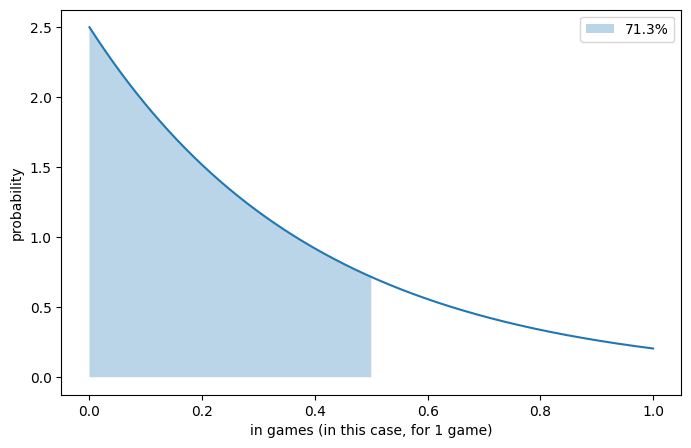

In [35]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(first_goal.index, first_goal)
ax.set_ylabel("probability")
ax.set_xlabel("in games (in this case, for 1 game)")
ax.fill_between(
    x_halftime,
    y_halftime,
    alpha=0.3,
    label=f"{round(first_goal_halftime_prob,3)*100}%",
)
ax.legend()
plt.show()

We can also use a CDF to calculate this.

In [36]:
expon_cdf = pd.Series(expon.cdf(x=x_ticks, scale=(1 / 2.5)), index=x_ticks)
halfway = expon_cdf.index.get_indexer([0.5], method="nearest")[0]

In [37]:
x_ticks = np.linspace(0, 1, 2000)
first_goal_cdf = pd.Series(expon_cdf, index=expon_cdf.index)
first_goal_cdf

0.000000    0.000000
0.001001    0.002499
0.002002    0.004993
0.003003    0.007479
0.004004    0.009960
              ...   
0.995996    0.917089
0.996997    0.917296
0.997998    0.917503
0.998999    0.917709
1.000000    0.917915
Length: 1000, dtype: float64

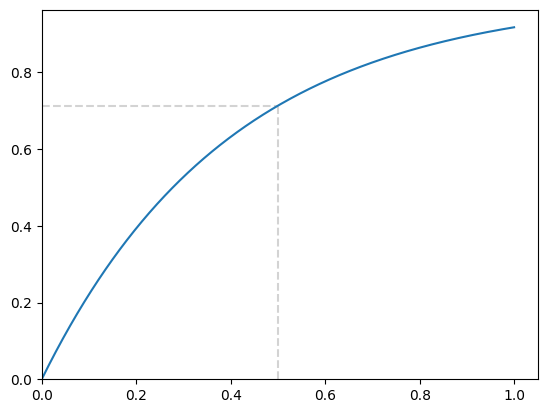

In [38]:
fig, ax = plt.subplots()
ax.vlines(
    x=0.5, ymin=0, ymax=expon_cdf.iloc[halfway], linestyle="--", color="lightgray"
)
ax.hlines(expon_cdf.iloc[halfway], xmax=0.5, xmin=0, linestyle="--", color="lightgray")
ax.plot(first_goal_cdf.index, first_goal_cdf)
ax.set_xlim(0)
ax.set_ylim(0)
plt.show()

## Glossary from the resource

- **continuous:** A quantity is continuous if it can have any value in a range on the number line. Most things we measure in the world – like weight, distance, and time – are continuous.
- **discrete:** A quantity is discrete if it can have a limited set of values, like integers or categories. Exact counts are discrete, as well as categorical variables.
- **probability density function (PDF):** A function that shows how density (not probability) is spread across the values of a continuous variable. The area under the PDF within an interval gives the probability that the variable falls in that interval range.
- **probability density:** The value of a PDF at a specific point; it’s not a probability itself, but it can be used to compute a probability.
- **kernel density estimation (KDE):** A method for estimating a PDF based on a sample.
- **discretize:** To approximate a continuous quantity by dividing its range into discrete levels or categories.